In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from sklearn.metrics import  confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting
from tensorflow.keras.layers import PReLU
from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models

In [7]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [8]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [9]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [10]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [11]:
X_train_cnn = X_train.reshape(-1, 28, 28,1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [12]:
cnn = Sequential([

    # -------- Block 1 --------
    Conv2D(32, (3,3), padding="same", input_shape=(28,28,1)),
    BatchNormalization(),
    PReLU(),
    MaxPooling2D((2,2)),

    # -------- Block 2 --------
    Conv2D(64, (3,3), padding="same"),
    BatchNormalization(),
    PReLU(),
    MaxPooling2D((2,2)),

    # -------- Block 3 --------
    Conv2D(128, (3,3), padding="same"),
    BatchNormalization(),
    PReLU(),
    MaxPooling2D((2,2)),   # Safe: 28 → 14 → 7 → 3

    # -------- Fully Connected --------
    Flatten(),

    Dense(128),
    BatchNormalization(),
    PReLU(),
    Dropout(0.4),

    Dense(10, activation="softmax")
])

- 28×28 → Conv(same) → 28×28 → Pool →
14×14.

- 14×14 → Conv(same) → 14×14 → Pool → 7×7
- 7×7   → Conv(same) → 7×7   → Pool → 3×3


In [13]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [14]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=30, batch_size=32, validation_data=(X_test_cnn, y_test_cat), verbose=1)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.9390 - loss: 0.2137 - val_accuracy: 0.9844 - val_loss: 0.0512
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9859 - loss: 0.0467 - val_accuracy: 0.9837 - val_loss: 0.0503
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9896 - loss: 0.0337 - val_accuracy: 0.9908 - val_loss: 0.0285
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9916 - loss: 0.0277 - val_accuracy: 0.9901 - val_loss: 0.0324
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9927 - loss: 0.0224 - val_accuracy: 0.9921 - val_loss: 0.0253
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9937 - loss: 0.0190 - val_accuracy: 0.9902 - val_loss: 0.0305
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9946 - loss: 0.0164 - val_accuracy: 0.9921 - val_loss: 0.0261
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9955 - loss: 0

In [15]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]

In [16]:
acc_cnn

0.9929999709129333

In [17]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

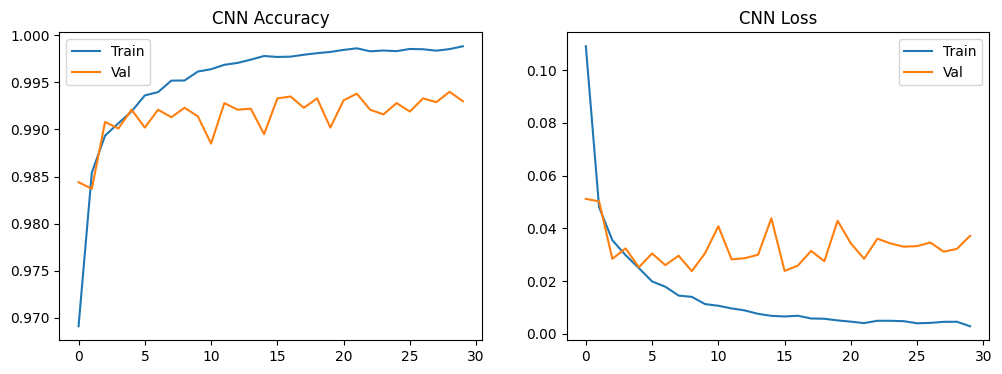

In [18]:
plot_training(history_cnn, "CNN")

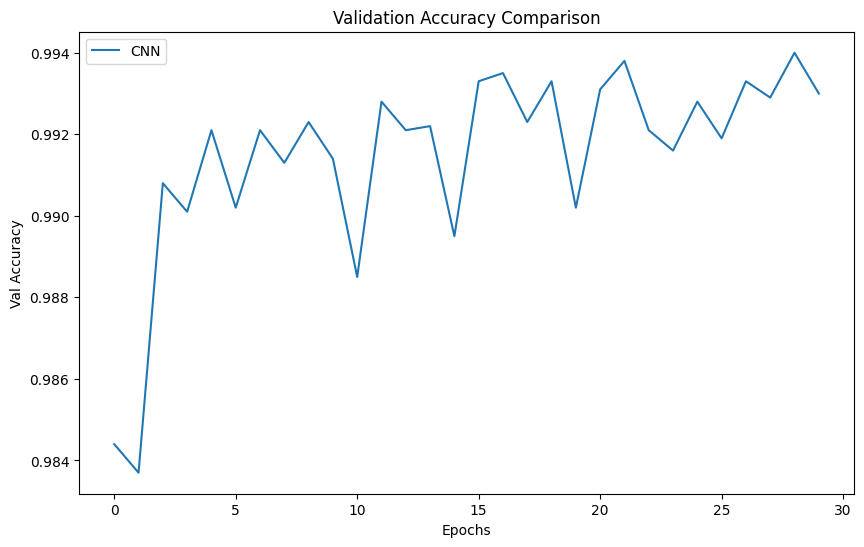

In [19]:
plt.figure(figsize=(10,6))
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [20]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


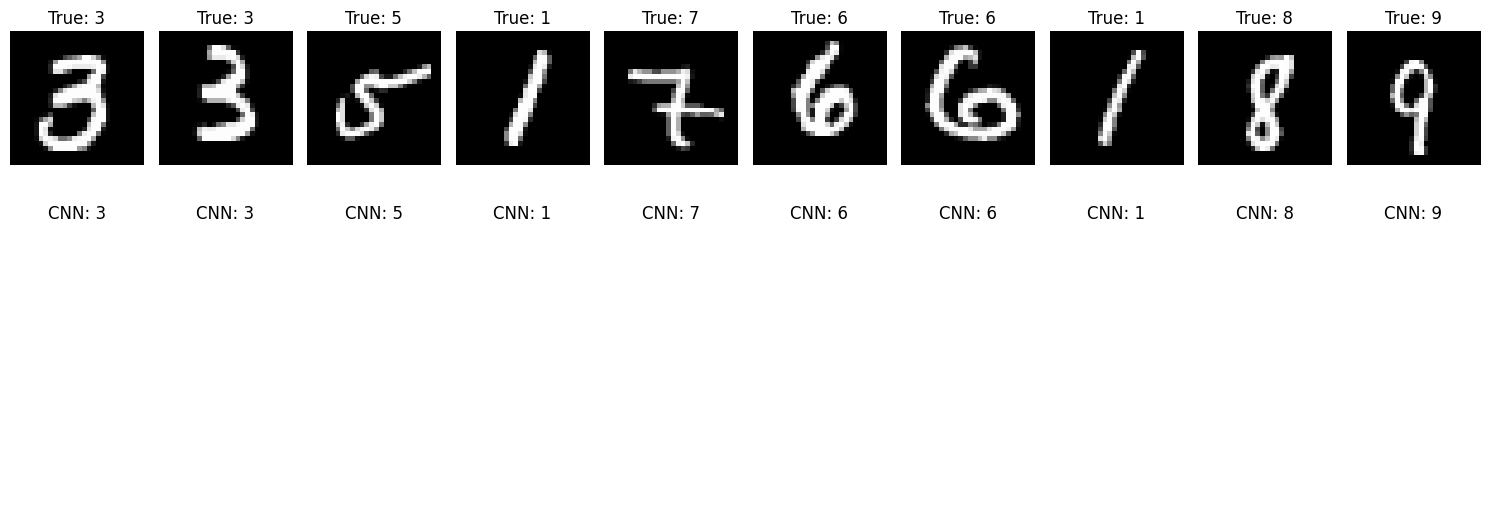

In [22]:
show_side_by_side([cnn], ["CNN"], X_test_img, X_test_cnn, y_test, 10)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


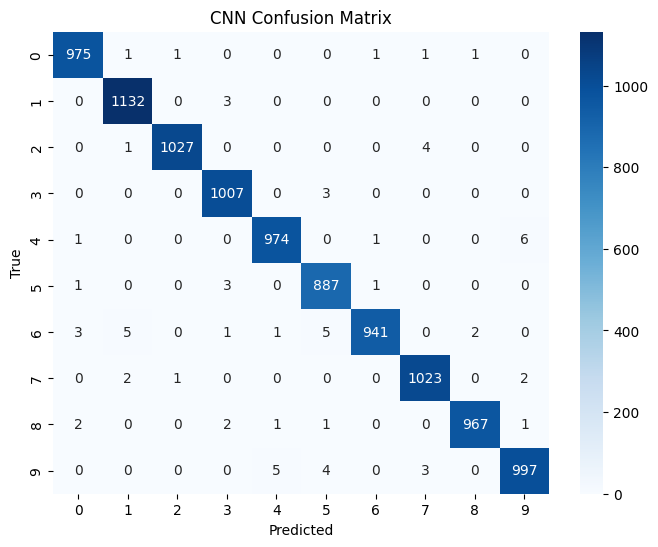

In [23]:
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [24]:
!pip install opencv-python

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [26]:
def preprocess_image(image_path):
    # Read image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Resize to 28x28 (MNIST size)
    img = cv2.resize(img, (28, 28))

    # Invert image (MNIST has white digit on black background)
    #img = cv2.bitwise_not(img)

    # Normalize pixel values (0–1)
    img = img / 255.0

    # Reshape to match CNN input: (1, 28, 28, 1)
    img = img.reshape(1, 28, 28, 1)

    return img


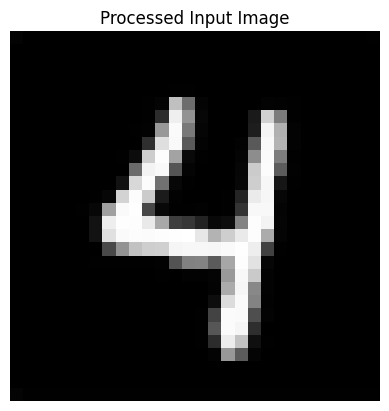

In [30]:
image_path = "/content/images (1).jpg"   # 🔁 change to your image path

processed_img = preprocess_image(image_path)

plt.imshow(processed_img.reshape(28,28), cmap="gray")
plt.title("Processed Input Image")
plt.axis("off")
plt.show()


In [31]:
prediction = cnn.predict(processed_img)

predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Digit: 4


In [32]:
for i, prob in enumerate(prediction[0]):
    print(f"Digit {i}: {prob:.4f}")


Digit 0: 0.0000
Digit 1: 0.0000
Digit 2: 0.0000
Digit 3: 0.0000
Digit 4: 1.0000
Digit 5: 0.0000
Digit 6: 0.0000
Digit 7: 0.0000
Digit 8: 0.0000
Digit 9: 0.0000


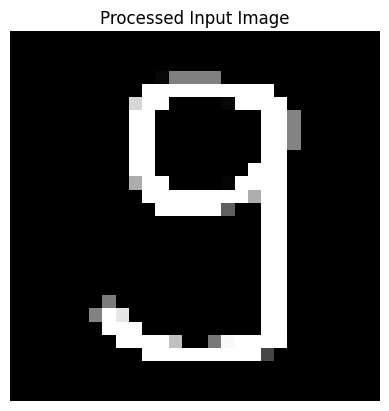

In [33]:
image_path = "/content/Untitled.png"   # 🔁 change to your image path

processed_img = preprocess_image(image_path)

plt.imshow(processed_img.reshape(28,28), cmap="gray")
plt.title("Processed Input Image")
plt.axis("off")
plt.show()


In [34]:
prediction = cnn.predict(processed_img)

predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted Digit: 9


In [35]:
for i, prob in enumerate(prediction[0]):
    print(f"Digit {i}: {prob:.4f}")


Digit 0: 0.0000
Digit 1: 0.0000
Digit 2: 0.0000
Digit 3: 0.0037
Digit 4: 0.0000
Digit 5: 0.0002
Digit 6: 0.0000
Digit 7: 0.0000
Digit 8: 0.0000
Digit 9: 0.9961


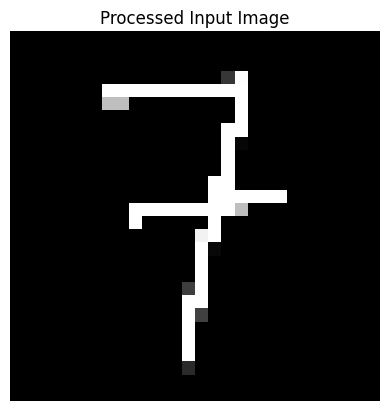

In [39]:
image_path = "/content/1769837774.png"   # 🔁 change to your image path

processed_img = preprocess_image(image_path)

plt.imshow(processed_img.reshape(28,28), cmap="gray")
plt.title("Processed Input Image")
plt.axis("off")
plt.show()


In [40]:
prediction = cnn.predict(processed_img)

predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted Digit: 7


In [41]:
for i, prob in enumerate(prediction[0]):
    print(f"Digit {i}: {prob:.4f}")


Digit 0: 0.0000
Digit 1: 0.0000
Digit 2: 0.0000
Digit 3: 0.0003
Digit 4: 0.0000
Digit 5: 0.0000
Digit 6: 0.0000
Digit 7: 0.9997
Digit 8: 0.0000
Digit 9: 0.0000
